# 第4章: 言語解析

問題30から問題35までは、以下の文章`text`（太宰治の『走れメロス』の冒頭部分）に対して、言語解析を実施せよ。問題36から問題39までは、国家を説明した文書群（日本語版ウィキペディア記事から抽出したテキスト群）をコーパスとして、言語解析を実施せよ。

Chương 4: Phân tích ngôn ngữ

Từ bài 30 đến bài 35, hãy thực hiện phân tích ngôn ngữ trên đoạn văn sau (phần mở đầu của 走れメロス của 太宰治):

In [1]:
text = """
メロスは激怒した。
必ず、かの邪智暴虐の王を除かなければならぬと決意した。
メロスには政治がわからぬ。
メロスは、村の牧人である。
笛を吹き、羊と遊んで暮して来た。
けれども邪悪に対しては、人一倍に敏感であった。
"""

In [2]:
#!pip install ginza ja-ginza

In [3]:
import spacy
import ginza
import pkg_resources

print(spacy.__version__)
print(pkg_resources.get_distribution("ginza").version)
print(pkg_resources.get_distribution("ja-ginza").version)

3.7.5
5.2.0
5.2.0


/tmp/ipykernel_11005/1808422088.py:3: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


In [4]:
#!pip install spacy==3.7.5

In [5]:
import spacy
import ginza

nlp = spacy.load("ja_ginza")

doc = nlp("メロスは激怒した。")

for token in doc:
    print(token.text, token.lemma_, token.pos_, token.dep_, token.head.text)

メロス メロス PROPN nsubj 激怒
は は ADP case メロス
激怒 激怒 VERB ROOT 激怒
し する AUX aux 激怒
た た AUX aux 激怒
。 。 PUNCT punct 激怒


In [ ]:
import spacy

nlp = spacy.load("ja_ginza")

doc = nlp(text)

for token in doc:
    print(
        token.text,
        token.lemma_,
        token.pos_,
        token.dep_,
        token.head.text
    )

## 30. 動詞
文章`text`に含まれる動詞をすべて表示せよ。

30. Động từ

Hãy hiển thị toàn bộ động từ xuất hiện trong đoạn văn text.

In [6]:
# version 1

import spacy

nlp = spacy.load("ja_ginza")

doc = nlp(text)

for token in doc:
    if token.pos_ in ["VERB", "AUX"]:
        print(
            token.text,
            token.pos_
        )

激怒 VERB
し AUX
た AUX
邪智 VERB
除か VERB
なけれ AUX
なら VERB
ぬ AUX
決意 VERB
し AUX
た AUX
わから VERB
ぬ AUX
で AUX
ある VERB
吹き VERB
遊ん VERB
暮し VERB
来 VERB
た AUX
対し VERB
で AUX
あっ VERB
た AUX


## 31. 動詞の原型
文章`text`に含まれる動詞と、その原型をすべて表示せよ。

31. Nguyên mẫu của động từ

Hãy hiển thị:

- các động từ xuất hiện trong text
- và nguyên mẫu (dictionary form) của chúng.

In [7]:
import spacy

nlp = spacy.load("ja_ginza")

doc = nlp(text)

for token in doc:
    if token.pos_ in ["VERB", "AUX"]:
        print(
            token.text,
            token.lemma_,
            token.pos_
        )

激怒 激怒 VERB
し する AUX
た た AUX
邪智 邪智 VERB
除か 除く VERB
なけれ ない AUX
なら なる VERB
ぬ ぬ AUX
決意 決意 VERB
し する AUX
た た AUX
わから わかる VERB
ぬ ぬ AUX
で だ AUX
ある ある VERB
吹き 吹く VERB
遊ん 遊ぶ VERB
暮し 暮す VERB
来 来る VERB
た た AUX
対し 対する VERB
で だ AUX
あっ ある VERB
た た AUX


## 32. 「AのB」
文章`text`において、2つの名詞が「の」で連結されている名詞句をすべて抽出せよ。

32. “A の B”

Trong đoạn văn text, hãy trích xuất toàn bộ cụm danh từ có dạng:

A の B

tức là:

- hai danh từ được nối bằng:
の

In [8]:
# version 1

import spacy

nlp = spacy.load("ja_ginza")

doc = nlp(text)

tokens = list(doc)

for i in range(len(tokens) - 2):
    if tokens[i].pos_ in ["NOUN", "PROPN"] and tokens[i + 1].text == "の" and tokens[i + 2].pos_ in ["NOUN", "PROPN"]:
        print(tokens[i].text, tokens[i + 1].text, tokens[i + 2].text)

暴虐 の 王
村 の 牧人


In [9]:
# version 2

import spacy

nlp = spacy.load("ja_ginza")

doc = nlp(text)

tokens = list(doc)
noun_tags = ["NOUN", "PROPN"]

for i in range(len(tokens) - 2):
    left = tokens[i]
    middle = tokens[i + 1]
    right = tokens[i + 2]

    if left.pos_ in noun_tags and middle.text == "の" and right.pos_ in noun_tags:
        print(left.text + middle.text + right.text)

暴虐の王
村の牧人


## 33. 係り受け解析

文章`text`に係り受け解析を適用し、係り元と係り先のトークン（形態素や文節などの単位）をタブ区切り形式ですべて抽出せよ。

33. Phân tích dependency (係り受け解析)

Hãy áp dụng dependency parsing lên text, rồi trích xuất:

- token phụ thuộc
- token mà nó phụ thuộc vào

(theo đơn vị như:
- morpheme,
- bunsetsu,
- ...)

và hiển thị theo định dạng tab-separated.

In [10]:
# version 1

import spacy

nlp = spacy.load("ja_ginza")

doc = nlp(text)

for token in doc:
    if token.dep_ != "ROOT":
        print(token.text, token.dep_, token.head.text, sep="\t")


	compound	メロス
メロス	nsubj	激怒
は	case	メロス
し	aux	激怒
た	aux	激怒
。	punct	激怒
必ず	advmod	除か
、	punct	必ず
かの	det	暴虐
邪智	compound	暴虐
暴虐	nmod	王
の	case	暴虐
王	obj	除か
を	case	王
除か	advcl	決意
なけれ	aux	除か
ば	fixed	なけれ
なら	fixed	なけれ
ぬ	fixed	なけれ
と	case	除か
し	aux	決意
た	aux	決意
。	punct	決意

	compound	メロス
メロス	obl	わから
に	case	メロス
は	case	メロス
政治	nsubj	わから
が	case	政治
ぬ	aux	わから
。	punct	わから

	compound	メロス
メロス	nsubj	牧人
は	case	メロス
、	punct	メロス
村	nmod	牧人
の	case	村
で	cop	牧人
ある	fixed	で
。	punct	牧人

	compound	笛
笛	obj	吹き
を	case	笛
吹き	advcl	暮し
、	punct	吹き
羊	obl	遊ん
と	case	羊
遊ん	advcl	暮し
で	mark	遊ん
て	mark	暮し
来	fixed	て
た	aux	暮し
。	punct	暮し

	obl	邪悪
けれど	case	

も	case	

邪悪	obl	敏感
に	case	邪悪
対し	fixed	に
ては	fixed	に
、	punct	邪悪
人	compound	倍
一	nummod	倍
倍	obl	敏感
に	case	倍
で	aux	敏感
あっ	fixed	で
た	aux	敏感
。	punct	敏感


In [11]:
# version 2
import spacy

nlp = spacy.load("ja_ginza")

doc = nlp(text)

for token in doc:
    if token.dep_ != "ROOT" and token.pos_ != "PUNCT":
        source = token.text
        target = token.head.text

        print(source, token.pos_, token.dep_, target, sep="\t")



	NUM	compound	メロス
メロス	PROPN	nsubj	激怒
は	ADP	case	メロス
し	AUX	aux	激怒
た	AUX	aux	激怒
必ず	ADV	advmod	除か
かの	DET	det	暴虐
邪智	VERB	compound	暴虐
暴虐	NOUN	nmod	王
の	ADP	case	暴虐
王	NOUN	obj	除か
を	ADP	case	王
除か	VERB	advcl	決意
なけれ	AUX	aux	除か
ば	SCONJ	fixed	なけれ
なら	VERB	fixed	なけれ
ぬ	AUX	fixed	なけれ
と	ADP	case	除か
し	AUX	aux	決意
た	AUX	aux	決意

	NUM	compound	メロス
メロス	PROPN	obl	わから
に	ADP	case	メロス
は	ADP	case	メロス
政治	NOUN	nsubj	わから
が	ADP	case	政治
ぬ	AUX	aux	わから

	NUM	compound	メロス
メロス	PROPN	nsubj	牧人
は	ADP	case	メロス
村	NOUN	nmod	牧人
の	ADP	case	村
で	AUX	cop	牧人
ある	VERB	fixed	で

	NUM	compound	笛
笛	NOUN	obj	吹き
を	ADP	case	笛
吹き	VERB	advcl	暮し
羊	NOUN	obl	遊ん
と	ADP	case	羊
遊ん	VERB	advcl	暮し
で	SCONJ	mark	遊ん
て	SCONJ	mark	暮し
来	VERB	fixed	て
た	AUX	aux	暮し

	NUM	obl	邪悪
けれど	CCONJ	case	

も	ADP	case	

邪悪	ADJ	obl	敏感
に	ADP	case	邪悪
対し	VERB	fixed	に
ては	SCONJ	fixed	に
人	NOUN	compound	倍
一	NUM	nummod	倍
倍	NOUN	obl	敏感
に	ADP	case	倍
で	AUX	aux	敏感
あっ	VERB	fixed	で
た	AUX	aux	敏感


## 34. 主述の関係
文章`text`において、「メロス」が主語であるときの述語を抽出せよ。

34. Quan hệ chủ-vị

Trong text, khi:

メロス

(Melos)

là chủ ngữ, hãy trích xuất vị ngữ tương ứng.

In [12]:
# version 1

import spacy

nlp = spacy.load("ja_ginza")

doc = nlp(text)

for token in doc:
    if token.text == "メロス" and token.dep_ == "nsubj":
        print(token.text, token.head.text)

メロス 激怒
メロス 牧人


In [13]:
# version 2

import spacy

nlp = spacy.load("ja_ginza")

doc = nlp(text)

for token in doc:
    if token.lemma_ == "メロス" and token.dep_ == "nsubj":
        print(token.text, token.head.text)

メロス 激怒
メロス 牧人


## 35. 係り受け木
「メロスは激怒した。」の係り受け木を可視化せよ。

35. Cây dependency

Hãy trực quan hóa dependency tree của câu:

メロスは激怒した。

In [14]:
import spacy

sentence = "メロスは激怒した。"

nlp = spacy.load("ja_ginza")

doc = nlp(sentence)

for token in doc:
    print(
        token.text,
        token.dep_,
        token.head.text
    )

メロス nsubj 激怒
は case メロス
激怒 ROOT 激怒
し aux 激怒
た aux 激怒
。 punct 激怒


In [15]:
from collections import defaultdict

children = defaultdict(list)
root = None

for token in doc:
    if token.dep_ == "ROOT":
        root = token
    else:
        children[token.head].append(token)


def print_tree(node, prefix="", is_last=True):
    connector = "└── " if is_last else "├── "

    if prefix == "":
        print(f"{node.text} ({node.dep_})")
    else:
        print(prefix + connector + f"{node.text} ({node.dep_})")

    new_prefix = prefix + ("    " if is_last else "│   ")

    for i, child in enumerate(children[node]):
        print_tree(
            child,
            new_prefix,
            i == len(children[node]) - 1
        )


print_tree(root)

激怒 (ROOT)
    ├── メロス (nsubj)
    │   └── は (case)
    ├── し (aux)
    ├── た (aux)
    └── 。 (punct)


## 36. 単語の出現頻度

問題36から39までは、Wikipediaの記事を以下のフォーマットで書き出したファイル[jawiki-country.json.gz](/data/jawiki-country.json.gz)をコーパスと見なし、統計的な分析を行う。

* 1行に1記事の情報がJSON形式で格納される
* 各行には記事名が"title"キーに、記事本文が"text"キーの辞書オブジェクトに格納され、そのオブジェクトがJSON形式で書き出される
* ファイル全体はgzipで圧縮される

まず、第3章の処理内容を参考に、Wikipedia記事からマークアップを除去し、各記事のテキストを抽出せよ。そして、コーパスにおける単語（形態素）の出現頻度を求め、出現頻度の高い20語とその出現頻度を表示せよ。


# Từ bài 36 trở đi

Từ bài 36 đến bài 39, hãy xem file:

jawiki-country.json.gz

(là tập các bài viết Wikipedia tiếng Nhật về quốc gia)

như một corpus để thực hiện phân tích thống kê.

Định dạng file:

- mỗi dòng là một article ở dạng JSON
- "title" chứa tên bài
- "text" chứa nội dung bài
- toàn bộ file được nén gzip

36. Tần suất xuất hiện của từ

Dựa trên nội dung xử lý ở chương 3:

- loại bỏ MediaWiki markup khỏi article
- trích xuất text của từng bài

Sau đó:

- tính tần suất xuất hiện của các từ (morpheme) trong corpus
- hiển thị:
  - 20 từ xuất hiện nhiều nhất
  - và số lần xuất hiện của chúng.

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
!find /content/drive/MyDrive -name "jawiki-country.json.gz"

/content/drive/MyDrive/Colab Notebooks/nlp100/data/jawiki-country.json.gz


In [18]:
# load data
import gzip
import json

#file="../data/jawiki-country.json.gz"

from pathlib import Path

ROOT = Path("/content/drive/MyDrive/Colab Notebooks/nlp100")
DATA = ROOT / "data"

file = DATA / "jawiki-country.json.gz"

articles = []

with gzip.open(file, "rt", encoding="utf-8") as f:
    for line in f:
        articles.append(json.loads(line))

print(len(articles))
print(articles[0].keys())

248
dict_keys(['title', 'text'])


In [19]:
# remove markup

import re

def clean_text(text):
    text = remove_emphasis(text)
    text = remove_internal_links(text)
    text = remove_html_tags(text)
    text = remove_language_template(text)
    text = remove_icon_templates(text)
    text = remove_layout_templates(text)
    #text = normalize_whitespace(text)
    return text

def remove_emphasis(text):
    return re.sub(r"'{2,5}", "", text)

def remove_internal_links(text):

    def repl(match):
        content = match.group(1)

        if "|" in content:
            return content.split("|")[-1]

        return content

    return re.sub(r"\[\[(.+?)\]\]", repl, text)

def remove_html_tags(text):
    text = re.sub(r"</?[^>]+>", " ", text)
    return text

def remove_language_template(text):
    #text = re.sub(r"\{\{lang\|(.+?)\|(.+?)\}\}", r"\2", text)

    def replace_language(match):
        content = match.group(1)
        return content.split("|")[-1]

    text = re.sub(r"\{\{lang\|(.+?)\}\}", replace_language, text)
    return text

def remove_icon_templates(text):
    text = re.sub(r"\{\{[^{}]*icon[^{}]*\}\}", "", text)
    return text

def remove_layout_templates(text):
    layout = ["center", "left", "right", "justify"]

    text = re.sub(r"\{\{(" + "|".join(layout) + r")\|(.+?)\}\}", r"\2", text)
    return text


def normalize_whitespace(text):
    text = re.sub(r"\s+", " ", text).strip()
    return text

for article in articles:
    text = article["text"]

    cleaned_text = clean_text(text)


In [31]:
# Ban đầu sử dụng spaCy/GiNZA nhưng gặp lỗi Input is too long ở một số bài.
# Chuyển sang dùng SudachiPy trực tiếp để thực hiện tách từ và lấy lemma.

from sudachipy import Dictionary, SplitMode
from collections import Counter
import pandas as pd

tokenizer = Dictionary().create()
mode = SplitMode.C

counter = Counter()

for article in articles:

    text = clean_text(article["text"])

    encoded = text.encode("utf-8")

    for start in range(0, len(encoded), 40000):

        piece = encoded[start:start+40000].decode(
            "utf-8",
            errors="ignore"
        )

        for token in tokenizer.tokenize(piece, mode):

            lemma = token.dictionary_form()

            counter[lemma] += 1

pd.DataFrame(
    counter.most_common(20),
    columns=["word", "frequency"]
)

,word,frequency
0,,208743
1,=,97341
2,の,95885
3,|,94690
4,、,88037
5,に,58181
6,\n,57780
7,。,53415
8,する,52411
9,は,52059


## 37. 名詞の出現頻度
コーパスにおける名詞の出現頻度を求め、出現頻度の高い20語とその出現頻度を表示せよ。

37. Tần suất xuất hiện của danh từ

Hãy:

- tính tần suất xuất hiện của các danh từ trong corpus
- hiển thị:
  - 20 danh từ xuất hiện nhiều nhất
  - cùng số lần xuất hiện.

In [32]:
from collections import Counter

counter = Counter()

for article in articles:

    text = clean_text(article["text"])

    encoded = text.encode("utf-8")

    for start in range(0, len(encoded), 40000):

        piece = encoded[start:start + 40000].decode(
            "utf-8",
            errors="ignore"
        )

        for token in tokenizer.tokenize(piece, mode):

            if token.part_of_speech()[0] != "名詞":
                continue

            counter[token.dictionary_form()] += 1

In [33]:
import pandas as pd

pd.DataFrame(
    counter.most_common(20),
    columns=["noun", "frequency"]
)

,noun,frequency
0,年,30561
1,月,13671
2,%,8609
3,2,7797
4,1,7496
5,en,5340
6,3,4708
7,こと,4603
8,日本,4447
9,リンク,4322


## 38. TF・IDF
日本に関する記事における名詞のTF・IDFスコアを求め、TF・IDFスコア上位20語とそのTF, IDF, TF・IDFを表示せよ。

38. TF-IDF

Trong bài viết về Nhật Bản:

- tính TF-IDF score của các danh từ
- hiển thị:
  - top 20 từ có TF-IDF cao nhất
  - cùng:
    - TF
    - IDF
    - TF-IDF

In [42]:
japan_article = None

for article in articles:
    if article["title"] == "日本":
        japan_article = article
        break

In [43]:
tf = Counter()

text = clean_text(japan_article["text"])

encoded = text.encode("utf-8")

for start in range(0, len(encoded), 40000):

    piece = encoded[start:start + 40000].decode(
        "utf-8",
        errors="ignore"
    )

    for token in tokenizer.tokenize(piece, mode):

        if token.part_of_speech()[0] != "名詞":
            continue

        lemma = token.dictionary_form()

        tf[lemma] += 1

In [44]:
df = Counter()

for article in articles:

    words_in_doc = set()

    text = clean_text(article["text"])

    encoded = text.encode("utf-8")

    for start in range(0, len(encoded), 40000):

        piece = encoded[start:start + 40000].decode(
            "utf-8",
            errors="ignore"
        )

        for token in tokenizer.tokenize(piece, mode):

            if token.part_of_speech()[0] != "名詞":
                continue

            lemma = token.dictionary_form()

            words_in_doc.add(lemma)

    for word in words_in_doc:
        df[word] += 1

In [45]:
N = len(articles)

In [46]:
import math

results = []

for word, tf_value in tf.items():

    idf_value = math.log(N / (df[word]))

    tfidf_value = tf_value * idf_value

    results.append(
        (word, tf_value, idf_value, tfidf_value)
    )

In [47]:
results.sort(
    key=lambda x: x[3],
    reverse=True
)

In [48]:
import pandas as pd

pd.DataFrame(
    results[:20],
    columns=[
        "word",
        "TF",
        "IDF",
        "TF-IDF"
    ]
)

,word,TF,IDF,TF-IDF
0,天皇,77,2.740840,211.044682
1,琉球,44,4.414816,194.251924
2,倭国,39,4.820282,187.990981
3,倭,38,4.820282,183.170699
4,KYUSHU,40,4.414816,176.592658
5,日本書紀,25,5.513429,137.835719
6,列島,45,2.874371,129.346714
7,明治,55,2.335375,128.445620
8,Museum,40,3.028522,121.140884
9,朝鮮,46,2.623057,120.660621


## 39. Zipfの法則
コーパスにおける単語の出現頻度順位を横軸、その出現頻度を縦軸として、両対数グラフをプロットせよ。

39. Định luật Zipf

Hãy:

- lấy:
  - trục hoành = thứ hạng tần suất của từ
  - trục tung = tần suất xuất hiện
- vẽ biểu đồ log-log.

In [49]:
freqs = counter.most_common()

In [50]:
ranks = []
values = []

for i, (word, freq) in enumerate(freqs, start=1):
    ranks.append(i)
    values.append(freq)

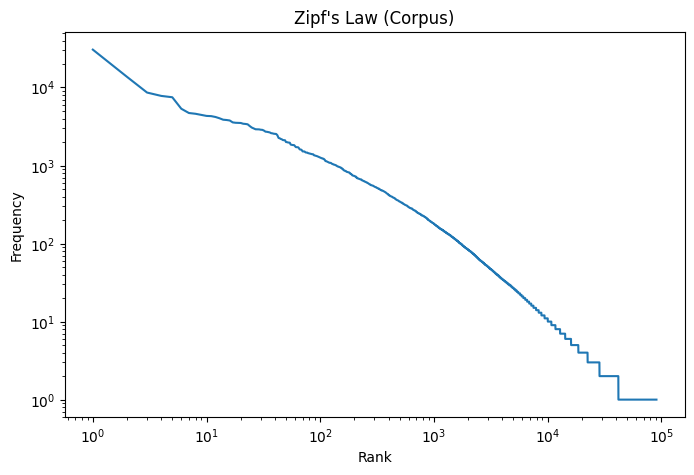

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.loglog(ranks, values)

plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Zipf's Law (Corpus)")
plt.show()